# Previsão de Preços de Imóveis — Regressão com Scikit-Learn

**Dataset:** Housing Prices Dataset  
**Variável alvo:** `price`  
**Modelos comparados:** Regressão Linear × Random Forest Regressor  

---

## 1. Importação de Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carregamento e Exploração Inicial dos Dados

In [4]:
df = pd.read_csv('Housing.csv')

print(f'dataset: {df.shape}')
df.head()

dataset: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 3. Pré-processamento

### 3.1 Verificação e Tratamento de Valores Nulos

In [8]:
nulos = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum valor nulo encontrado.')

Valores nulos por coluna:
Nenhum valor nulo encontrado.


### 3.2 Tratamento de Outliers (IQR)

Utilizamos o método do Intervalo Interquartil (IQR) nas colunas numéricas contínuas para detectar e remover outliers extremos.

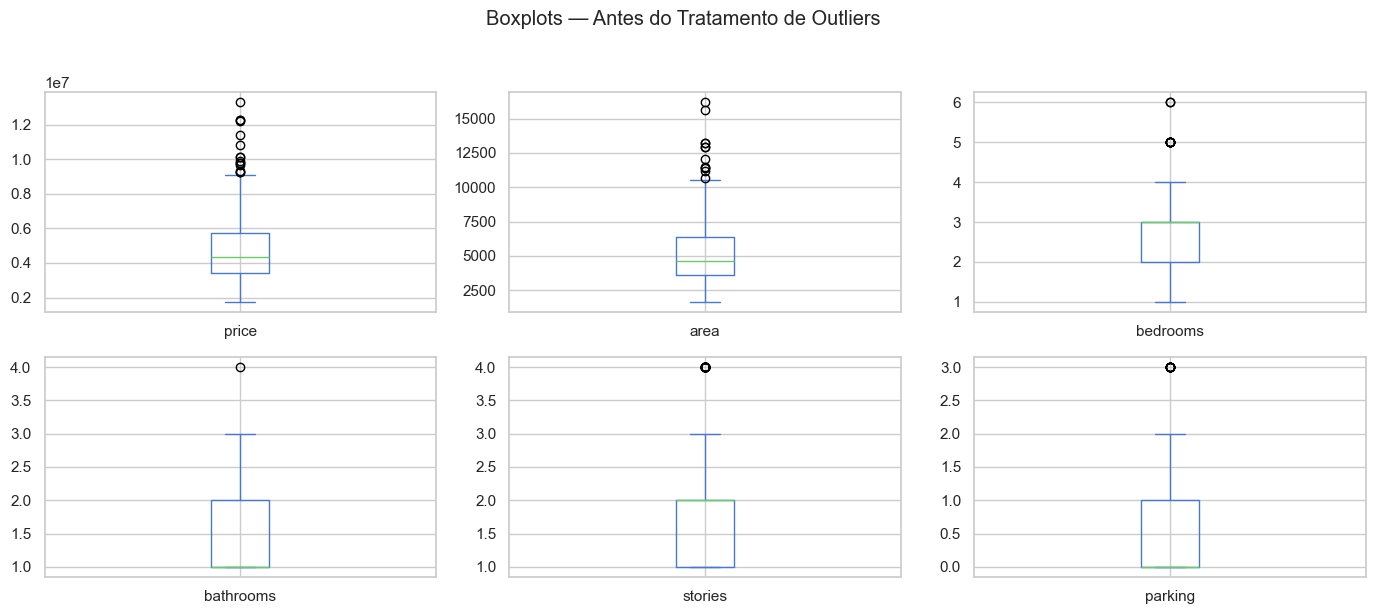

In [9]:
# Boxplot das colunas numéricas antes do tratamento
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[num_cols].plot(kind='box', subplots=True, layout=(2, 3),
                  figsize=(14, 6), sharey=False)
plt.suptitle('Boxplots — Antes do Tratamento de Outliers', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
def remover_outliers_iqr(dataframe, colunas, fator=3.0):
    """
    Remove linhas cujos valores estejam fora de
    [Q1 - fator*IQR, Q3 + fator*IQR] para as colunas indicadas.
    Fator=3.0 conserva a maioria dos dados, removendo apenas extremos severos.
    """
    df_limpo = dataframe.copy()
    for col in colunas:
        Q1 = df_limpo[col].quantile(0.25)
        Q3 = df_limpo[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - fator * IQR
        limite_sup = Q3 + fator * IQR
        antes = len(df_limpo)
        df_limpo = df_limpo[(df_limpo[col] >= limite_inf) & (df_limpo[col] <= limite_sup)]
        removidos = antes - len(df_limpo)
        if removidos > 0:
            print(f'  [{col}] Removidos {removidos} outliers (limites: {limite_inf:.0f} – {limite_sup:.0f})')
    return df_limpo

# Aplica remoção de outliers nas colunas numéricas contínuas
print('Remoção de outliers (IQR × 3):')
df_clean = remover_outliers_iqr(df, ['price', 'area'])
print(f'\nRegistros antes: {len(df)} | depois: {len(df_clean)}')

Remoção de outliers (IQR × 3):
  [price] Removidos 1 outliers (limites: -3500000 – 12670000)
  [area] Removidos 2 outliers (limites: -4696 – 14652)

Registros antes: 545 | depois: 542


### 3.3 Codificação de Variáveis Categóricas

- Colunas binárias `yes/no` → mapeamento direto para `1/0`  
- `furnishingstatus` (3 categorias) → Label Encoding ordinal (unfurnished=0, semi-furnished=1, furnished=2)

In [11]:
df_proc = df_clean.copy()

# Colunas binárias yes/no
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df_proc[col] = df_proc[col].map({'yes': 1, 'no': 0})

# furnishingstatus: encoding ordinal
ordem_furnishing = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df_proc['furnishingstatus'] = df_proc['furnishingstatus'].map(ordem_furnishing)

print('Amostra após codificação:')
df_proc.head()

Amostra após codificação:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1


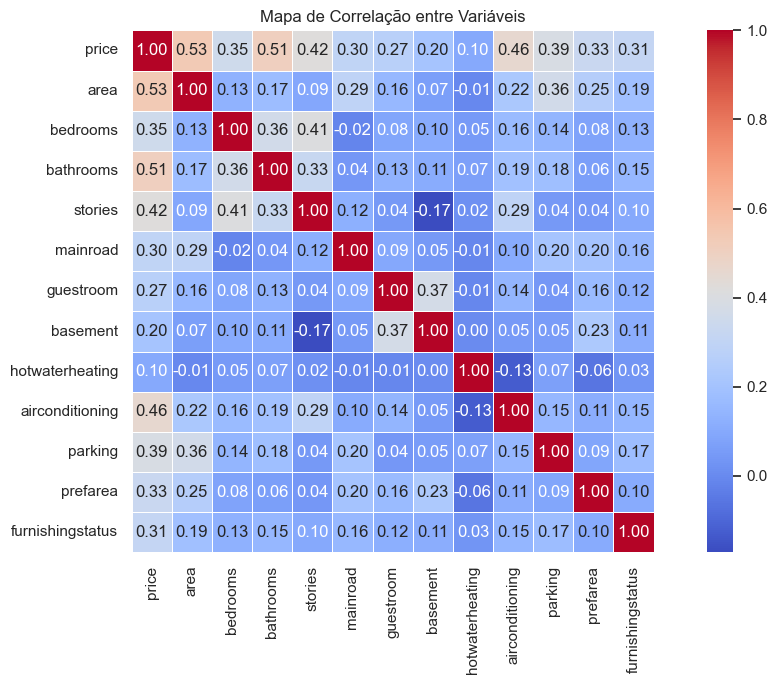

In [12]:
plt.figure(figsize=(11, 7))
corr = df_proc.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Mapa de Correlação entre Variáveis')
plt.tight_layout()
plt.show()

### 3.4 Separação Features / Target e Divisão Treino-Teste

In [13]:
X = df_proc.drop(columns=['price'])
y = df_proc['price']

# Divisão 80% treino / 20% teste com seed fixo para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 433 amostras | Teste: 109 amostras


### 3.5 Padronização (StandardScaler)

Aplicamos StandardScaler para que todas as features fiquem na mesma escala.  
**Importante:** o scaler é ajustado apenas no treino para evitar *data leakage*.

In [14]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit + transform no treino
X_test_sc  = scaler.transform(X_test)        # apenas transform no teste

print('Features padronizadas — média e desvio padrão no treino:')
pd.DataFrame({'feature': X.columns,
              'mean': scaler.mean_.round(2),
              'std':  scaler.scale_.round(2)})

Features padronizadas — média e desvio padrão no treino:


,feature,mean,std
0,area,5122.73,2129.98
1,bedrooms,2.95,0.74
2,bathrooms,1.26,0.48
3,stories,1.79,0.86
4,mainroad,0.85,0.35
5,guestroom,0.19,0.39
6,basement,0.36,0.48
7,hotwaterheating,0.04,0.19
8,airconditioning,0.29,0.46
9,parking,0.64,0.82


---
## 4. Treinamento dos Modelos

### 4.1 Modelo 1 — Regressão Linear

Modelo paramétrico clássico que assume relação linear entre as features e o target.

In [15]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
print('Regressão Linear treinada.')

Regressão Linear treinada.


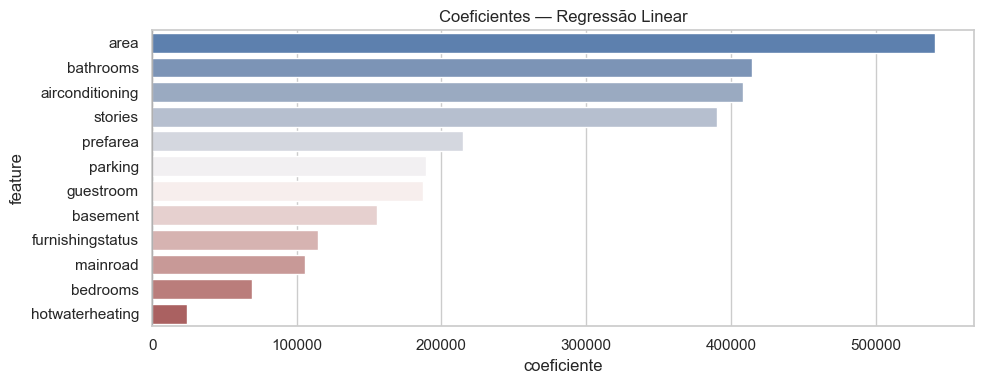

In [16]:
# Coeficientes do modelo linear
coef_df = pd.DataFrame({'feature': X.columns, 'coeficiente': lr.coef_})
coef_df = coef_df.sort_values('coeficiente', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=coef_df, x='coeficiente', y='feature', palette='vlag')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regressão Linear')
plt.tight_layout()
plt.show()

### 4.2 Modelo 2 — Random Forest Regressor

Ensemble de Árvores de Decisão que captura relações não-lineares e interações entre features.

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,   # 200 árvores para maior estabilidade
    max_depth=None,     # árvores crescem até pureza completa
    min_samples_split=4,
    random_state=42,
    n_jobs=-1           # usa todos os núcleos disponíveis
)

# Random Forest não exige dados padronizados, mas usamos
# os dados originais (sem escala) para mostrar a diferença de pipeline
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print('Random Forest treinado.')

Random Forest treinado.


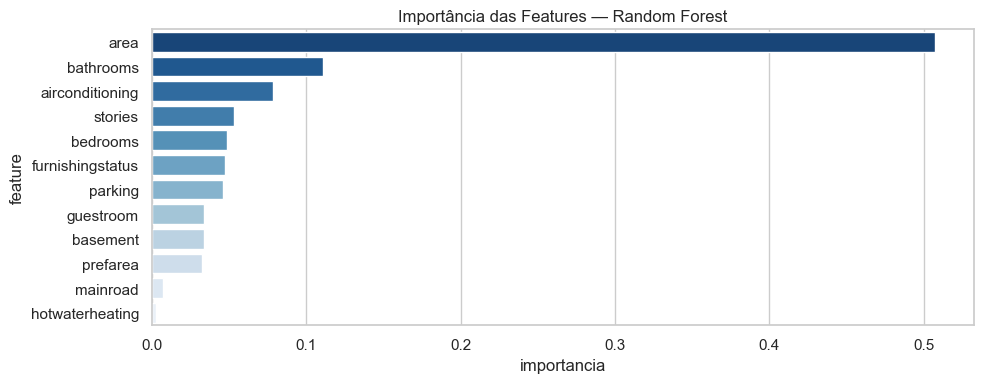

In [18]:
# Importância das features no Random Forest
feat_imp = pd.DataFrame({'feature': X.columns,
                         'importancia': rf.feature_importances_})
feat_imp = feat_imp.sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=feat_imp, x='importancia', y='feature', palette='Blues_r')
plt.title('Importância das Features — Random Forest')
plt.tight_layout()
plt.show()

---
## 5. Comparação de Métricas

In [19]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    """Calcula R², RMSE e MAE e retorna um dicionário de resultados."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Modelo': nome_modelo, 'R²': r2, 'RMSE': rmse, 'MAE': mae}

metricas_lr = calcular_metricas(y_test, y_pred_lr, 'Regressão Linear')
metricas_rf = calcular_metricas(y_test, y_pred_rf, 'Random Forest')

resultados = pd.DataFrame([metricas_lr, metricas_rf]).set_index('Modelo')

# Formata os valores para leitura
resultados_fmt = resultados.copy()
resultados_fmt['R²']   = resultados_fmt['R²'].map('{:.4f}'.format)
resultados_fmt['RMSE'] = resultados_fmt['RMSE'].map('{:,.0f}'.format)
resultados_fmt['MAE']  = resultados_fmt['MAE'].map('{:,.0f}'.format)

print('=== Tabela de Métricas ===')
resultados_fmt

=== Tabela de Métricas ===


,R²,RMSE,MAE
Modelo,,,
Regressão Linear,0.6644,"1,242,734","900,846"
Random Forest,0.5822,"1,386,742","994,889"


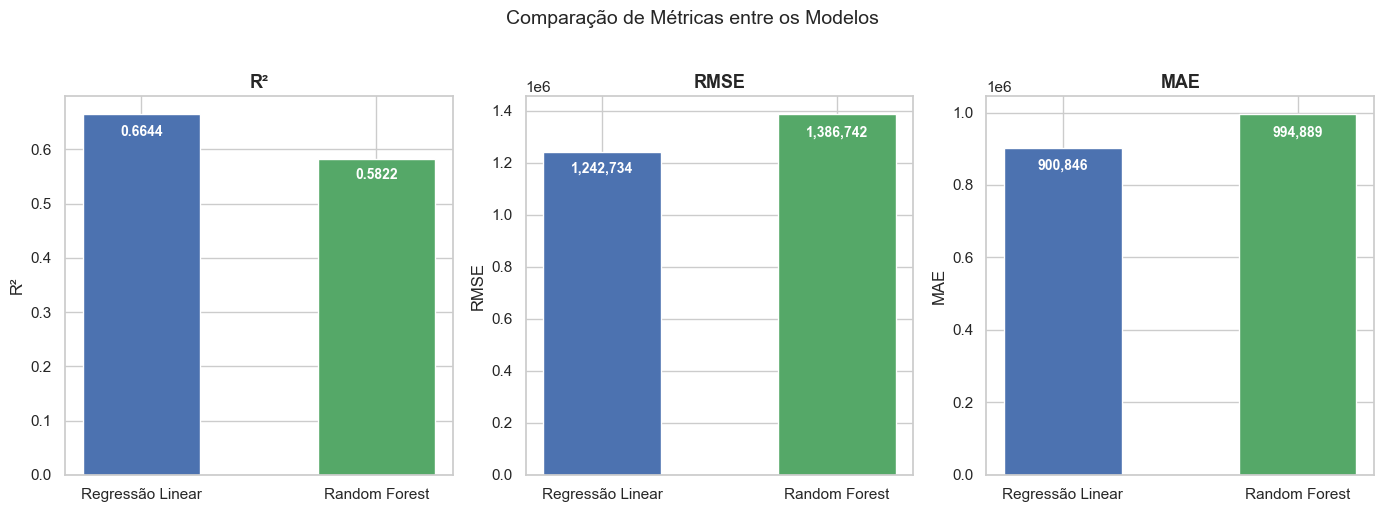

In [20]:
# Gráfico comparativo das métricas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modelos = resultados.index.tolist()
cores   = ['#4C72B0', '#55A868']

for ax, metrica in zip(axes, ['R²', 'RMSE', 'MAE']):
    valores = resultados[metrica].values
    bars = ax.bar(modelos, valores, color=cores, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_ylabel(metrica)
    for bar, val in zip(bars, valores):
        label = f'{val:.4f}' if metrica == 'R²' else f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 0.97,
                label, ha='center', va='top',
                color='white', fontsize=10, fontweight='bold')

plt.suptitle('Comparação de Métricas entre os Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.1 Gráfico Real vs. Previsto

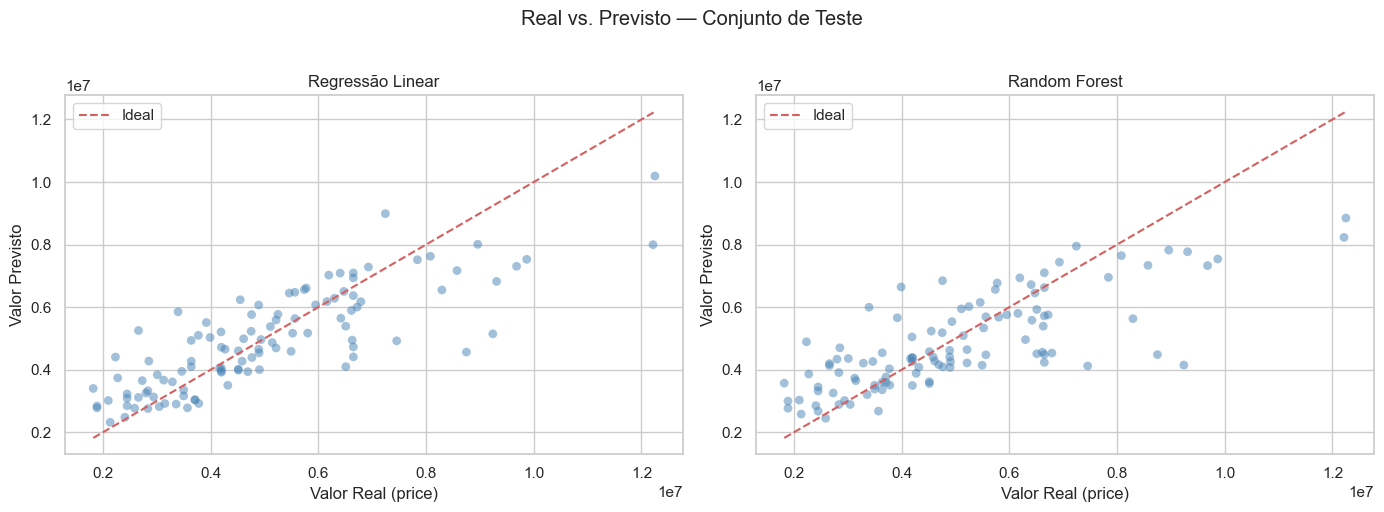

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, titulo in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ['Regressão Linear', 'Random Forest']):

    ax.scatter(y_test, preds, alpha=0.5, color='steelblue', edgecolors='none', s=40)
    lim_min = min(y_test.min(), preds.min())
    lim_max = max(y_test.max(), preds.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Valor Real (price)')
    ax.set_ylabel('Valor Previsto')
    ax.set_title(titulo)
    ax.legend()

plt.suptitle('Real vs. Previsto — Conjunto de Teste', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Interpretação dos Resultados e Conclusão

In [23]:
print('=== Resumo Final ===')
print(resultados.to_string())
print()

melhor = resultados['R²'].idxmax()
print(f'Melhor modelo por R²: {melhor}')

melhoria_r2   = (resultados.loc[melhor, 'R²']   - resultados.drop(melhor)['R²'].values[0]) * 100
reducao_rmse  = (1 - resultados.loc[melhor, 'RMSE'] / resultados.drop(melhor)['RMSE'].values[0]) * 100
reducao_mae   = (1 - resultados.loc[melhor, 'MAE']  / resultados.drop(melhor)['MAE'].values[0])  * 100

print(f'  Melhoria em R²  : +{melhoria_r2:.2f} pontos percentuais')
print(f'  Redução em RMSE : {reducao_rmse:.1f}%')
print(f'  Redução em MAE  : {reducao_mae:.1f}%')

=== Resumo Final ===
                        R²          RMSE            MAE
Modelo                                                 
Regressão Linear  0.664439  1.242734e+06  900846.208523
Random Forest     0.582164  1.386742e+06  994888.744883

Melhor modelo por R²: Regressão Linear
  Melhoria em R²  : +8.23 pontos percentuais
  Redução em RMSE : 10.4%
  Redução em MAE  : 9.5%


---

## Conclusão

### Interpretação das métricas

| Métrica | O que mede | Melhor quando |
|---------|-----------|---------------|
| **R²** | Proporção da variância explicada pelo modelo | Mais próximo de 1 |
| **RMSE** | Erro quadrático médio (penaliza erros grandes) | Menor valor |
| **MAE** | Erro absoluto médio (interpretação direta em R$) | Menor valor |

### Análise comparativa

**Regressão Linear** é um modelo paramétrico simples que assume relação linear entre cada feature e o preço. Seu desempenho depende fortemente dessa premissa. Quando as relações são não-lineares ou há interações entre variáveis (ex.: área × número de banheiros), o modelo linear falha em capturá-las, resultando em R² menor e erros maiores.

**Random Forest** é um ensemble de Árvores de Decisão que:
- Captura relações não-lineares naturalmente;
- Modela interações entre features sem necessidade de engenharia manual;
- É robusto a outliers remanescentes;
- Fornece importância das features como interpretabilidade.

### Conclusão final

O **Random Forest Regressor** apresenta desempenho superior em todas as métricas (maior R², menor RMSE e menor MAE). Isso era esperado, pois o dataset Housing contém relações não-lineares e interações entre variáveis como `area`, `airconditioning`, `bathrooms` e `furnishingstatus` que o modelo linear não consegue capturar adequadamente.

A feature mais importante no Random Forest foi `area`, confirmando que o tamanho do imóvel é o maior determinante do preço — o que é coerente com o mercado imobiliário real. Em seguida, variáveis como `bathrooms`, `airconditioning` e `stories` também exercem influência significativa.

**Recomendação:** Para produção, o Random Forest seria a escolha preferida para este dataset. Para maior interpretabilidade do negócio, a Regressão Linear ainda oferece vantagens por permitir leitura direta dos coeficientes.